In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [150]:
train = pd.read_csv("../../data/train.csv")
test = pd.read_csv("../../data/test.csv")

In [151]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

missing_train = set(missing_train[missing_train > 0].index)
missing_test  = set(missing_test[missing_test > 0].index)

print("Пропуски есть в трейне но не в тесте:")
print(missing_train - missing_test)

print("\nПропуски есть в тесте но не в трейне:")
print(missing_test - missing_train)

print("\nПропуски в обоих:")
print(missing_train & missing_test)

Пропуски есть в трейне но не в тесте:
{'Electrical'}

Пропуски есть в тесте но не в трейне:
{'BsmtFullBath', 'Functional', 'MSZoning', 'GarageArea', 'BsmtFinSF1', 'BsmtUnfSF', 'BsmtFinSF2', 'KitchenQual', 'Utilities', 'TotalBsmtSF', 'GarageCars', 'SaleType', 'Exterior1st', 'Exterior2nd', 'BsmtHalfBath'}

Пропуски в обоих:
{'GarageCond', 'Alley', 'BsmtFinType1', 'LotFrontage', 'MiscFeature', 'BsmtExposure', 'BsmtCond', 'GarageType', 'GarageFinish', 'GarageYrBlt', 'FireplaceQu', 'GarageQual', 'BsmtQual', 'PoolQC', 'MasVnrType', 'BsmtFinType2', 'Fence', 'MasVnrArea'}


In [152]:
y = np.log1p(train["SalePrice"])
ids = test["Id"]
n_train = len(train)

# Объединяем
df = pd.concat(
    [train.drop(columns=["Id", "SalePrice"]), test.drop(columns=["Id"])], axis=0
).reset_index(drop=True)

print("Размер:", df.shape)
print("\nТипы колонок:")
print(df.dtypes.value_counts())

Размер: (2919, 79)

Типы колонок:
str        43
int64      25
float64    11
Name: count, dtype: int64


In [153]:
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    n_unique = df[col].nunique()
    if top_freq > 0.90:
        print(f"{col:20s}  уникальных: {n_unique:3d}  доминирует: {top_freq:.1%}")

Street                уникальных:   2  доминирует: 99.6%
Utilities             уникальных:   2  доминирует: 100.0%
LandSlope             уникальных:   3  доминирует: 95.2%
Condition2            уникальных:   8  доминирует: 99.0%
RoofMatl              уникальных:   8  доминирует: 98.5%
BsmtCond              уникальных:   4  доминирует: 91.9%
Heating               уникальных:   6  доминирует: 98.5%
CentralAir            уникальных:   2  доминирует: 93.3%
Electrical            уникальных:   5  доминирует: 91.5%
LowQualFinSF          уникальных:  36  доминирует: 98.6%
BsmtHalfBath          уникальных:   3  доминирует: 94.0%
KitchenAbvGr          уникальных:   4  доминирует: 95.4%
Functional            уникальных:   7  доминирует: 93.1%
GarageQual            уникальных:   5  доминирует: 94.3%
GarageCond            уникальных:   5  доминирует: 96.2%
PavedDrive            уникальных:   3  доминирует: 90.5%
3SsnPorch             уникальных:  31  доминирует: 98.7%
ScreenPorch           уникальн

In [154]:
# IMPUTER

cols_drop = [
    "Street",
    "Utilities",
    "PoolQC",
    "PoolArea",
    "MiscFeature",
    "MiscVal",
    "Alley",
]

df = df.drop(columns=cols_drop)

In [155]:
print("Осталось колонок:", df.shape[1])

Осталось колонок: 72


In [156]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Колонок с пропусками: {len(missing)}")
print(missing)

Колонок с пропусками: 30
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageFinish     159
GarageYrBlt      159
GarageQual       159
GarageCond       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
BsmtHalfBath       2
Functional         2
GarageArea         1
GarageCars         1
Electrical         1
KitchenQual        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
SaleType           1
dtype: int64


In [157]:
# IMPUTER

# Текстовые — нет объекта
none_cols = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "Fence",
    "MasVnrType",
]
df[none_cols] = df[none_cols].fillna("NA")

# Числовые — нет объекта
zero_cols = [
    "GarageArea",
    "GarageCars",
    "GarageYrBlt",
    "MasVnrArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBsmtSF",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
]
df[zero_cols] = df[zero_cols].fillna(0)

In [158]:
# Проверка
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

LotFrontage    486
MSZoning         4
Functional       2
Exterior1st      1
Exterior2nd      1
Electrical       1
KitchenQual      1
SaleType         1
dtype: int64


In [159]:
# IMPUTER

# Группа 2 — мода (1-4 пропуска)
mode_cols = [
    "MSZoning",
    "Functional",
    "Exterior1st",
    "Exterior2nd",
    "Electrical",
    "KitchenQual",
    "SaleType",
]
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [160]:
# Проверка
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

LotFrontage    486
dtype: int64


In [161]:
# IMPUTER

df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Проверка — должно быть 0 пропусков
print(df.isnull().sum().sum())

0


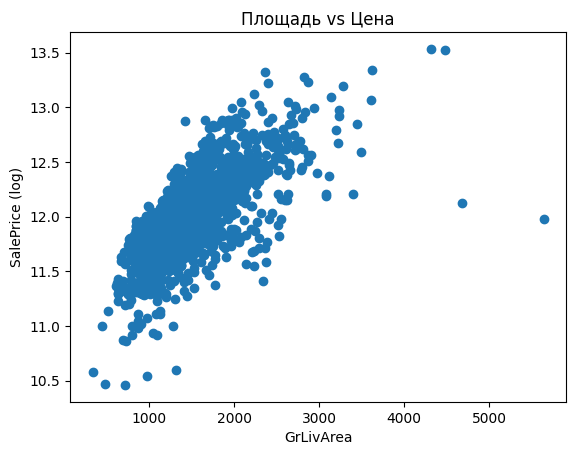

In [162]:
# Смотрим только на трейн (первые n_train строк)
train_df = df.iloc[:n_train].copy()
train_df["SalePrice"] = y

plt.scatter(train_df["GrLivArea"], train_df["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice (log)")
plt.title("Площадь vs Цена")
plt.show()

In [163]:
# IMPUTER

grlivarea_thresh = train_df["GrLivArea"].quantile(0.999)

outlier_idx = train_df[train_df["GrLivArea"] > grlivarea_thresh].index

print(f"Порог площади: {grlivarea_thresh:.0f}")
print(train_df.loc[outlier_idx, ["GrLivArea", "SalePrice"]])

df = df.drop(index=outlier_idx).reset_index(drop=True)
y = y.drop(index=outlier_idx).reset_index(drop=True)
n_train = n_train - len(outlier_idx)

print(f"Удалили: {len(outlier_idx)} выброса")
print(f"Новый размер трейна: {n_train}")

Порог площади: 4584
      GrLivArea  SalePrice
523        4676  12.126764
1298       5642  11.982935
Удалили: 2 выброса
Новый размер трейна: 1458


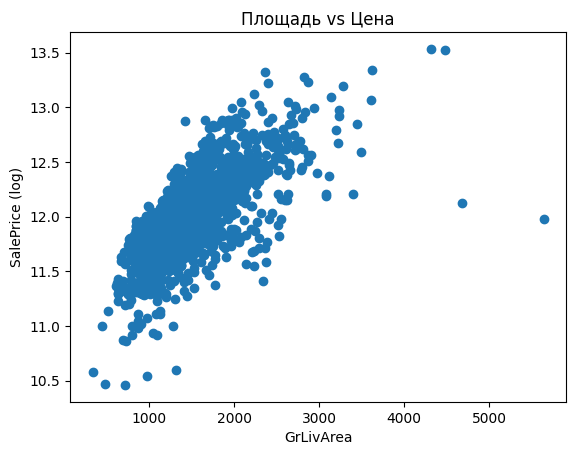

In [164]:
plt.scatter(train_df["GrLivArea"], train_df["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice (log)")
plt.title("Площадь vs Цена")
plt.show()

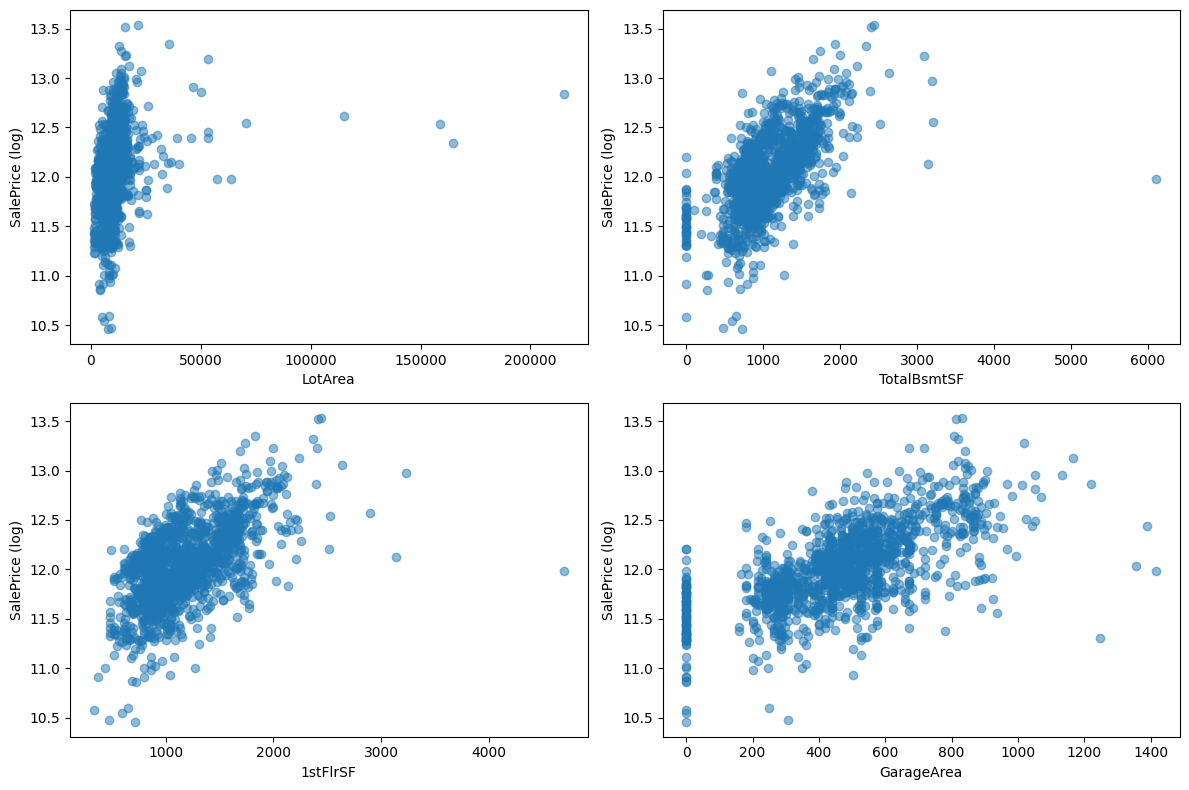

In [165]:
num_cols = ["LotArea", "TotalBsmtSF", "1stFlrSF", "GarageArea"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(train_df[col], train_df["SalePrice"], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice (log)")

plt.tight_layout()
plt.show()

In [166]:
print(train_df["LotArea"].quantile([0.95, 0.99, 0.999, 1.0]))
print()

# Смотрим кандидатов
thresh = train_df["LotArea"].quantile(0.999)
print(train_df[train_df["LotArea"] > thresh][["LotArea", "SalePrice"]])

0.950     17401.15
0.990     37567.64
0.999    162062.06
1.000    215245.00
Name: LotArea, dtype: float64

     LotArea  SalePrice
313   215245  12.834684
335   164660  12.341263


In [167]:
thresh = train_df["LotArea"].quantile(0.995)
print(train_df[train_df["LotArea"] > thresh][["LotArea", "SalePrice"]])

      LotArea  SalePrice
249    159000  12.531776
313    215245  12.834684
335    164660  12.341263
451     70761  12.542548
706    115149  12.618186
769     53504  13.195616
1298    63887  11.982935
1396    57200  11.982935


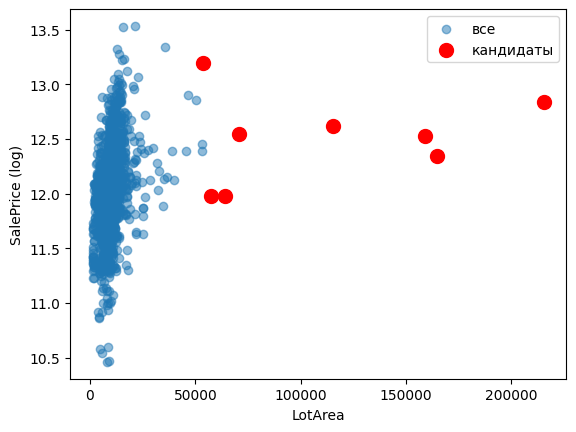

In [168]:
thresh = train_df["LotArea"].quantile(0.995)
outliers = train_df[train_df["LotArea"] > thresh]

plt.scatter(train_df["LotArea"], train_df["SalePrice"], alpha=0.5, label="все")
plt.scatter(
    outliers["LotArea"], outliers["SalePrice"], color="red", s=100, label="кандидаты"
)
plt.xlabel("LotArea")
plt.ylabel("SalePrice (log)")
plt.legend()
plt.show()

In [169]:
# IMPUTER

qual_map = {"NA": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
fin_map = {"NA": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
exp_map = {"NA": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
grg_map = {"NA": 0, "Unf": 1, "RFn": 2, "Fin": 3}
func_map = {
    "Sal": 0,
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7,
}

ordinal = {
    "ExterQual": qual_map,
    "ExterCond": qual_map,
    "HeatingQC": qual_map,
    "KitchenQual": qual_map,
    "FireplaceQu": qual_map,
    "GarageQual": qual_map,
    "GarageCond": qual_map,
    "BsmtQual": qual_map,
    "BsmtCond": qual_map,
    "BsmtFinType1": fin_map,
    "BsmtFinType2": fin_map,
    "BsmtExposure": exp_map,
    "GarageFinish": grg_map,
    "Functional": func_map,
    "LotShape": {"Reg": 3, "IR1": 2, "IR2": 1, "IR3": 0},
    "LandSlope": {"Gtl": 1, "Mod": 2, "Sev": 3},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "CentralAir": {"N": 0, "Y": 1},
}

for col, mapping in ordinal.items():
    df[col] = df[col].map(mapping)

# Проверка — не должно быть NaN
print(df[list(ordinal.keys())].isnull().sum())

ExterQual       0
ExterCond       0
HeatingQC       0
KitchenQual     0
FireplaceQu     0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtFinType1    0
BsmtFinType2    0
BsmtExposure    0
GarageFinish    0
Functional      0
LotShape        0
LandSlope       0
PavedDrive      0
CentralAir      0
dtype: int64


In [170]:
# IMPUTER

# Кладки нет, но площадь есть — ставим самый частый тип
most_common = df[df['MasVnrType'] != 'NA']['MasVnrType'].mode()[0]
mask1 = (df['MasVnrType'] == 'NA') & (df['MasVnrArea'] > 0)
df.loc[mask1, 'MasVnrType'] = most_common

# Кладка есть, но площадь 0 — убираем тип
mask2 = (df['MasVnrType'] != 'NA') & (df['MasVnrArea'] == 0)
df.loc[mask2, 'MasVnrType'] = 'NA'

# Проверка
print("Осталось противоречий:")
print("Кладки нет, площадь > 0:", ((df['MasVnrType'] == 'NA') & (df['MasVnrArea'] > 0)).sum())
print("Кладка есть, площадь = 0:", ((df['MasVnrType'] != 'NA') & (df['MasVnrArea'] == 0)).sum())

Осталось противоречий:
Кладки нет, площадь > 0: 0
Кладка есть, площадь = 0: 0


In [171]:
# IMPUTER

# Возраст
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

# Площади
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["TotalPorchSF"] = (
    df["OpenPorchSF"] + df["EnclosedPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]
)

# Ванные
df["TotalBath"] = (
    df["FullBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["HalfBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Флаги
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["HasPorch"] = (df["TotalPorchSF"] > 0).astype(int)

# Interaction: качество × площадь
df["QualSF"] = df["OverallQual"] * df["GrLivArea"]
df["QualTotalSF"] = df["OverallQual"] * df["TotalSF"]

print(f"Итого колонок: {df.shape[1]}")

Итого колонок: 83


In [172]:
# Проверяем все зависимые колонки
checks = [
    # Камин
    ("Камин есть, качество NA",     (df['Fireplaces'] > 0) & (df['FireplaceQu'] == 'NA')),
    ("Камина нет, качество не NA",  (df['Fireplaces'] == 0) & (df['FireplaceQu'] != 'NA')),
    
    # Гараж
    ("Гараж есть, тип NA",          (df['GarageArea'] > 0) & (df['GarageType'] == 'NA')),
    ("Гаража нет, машины > 0",      (df['GarageArea'] == 0) & (df['GarageCars'] > 0)),
    ("Гаража нет, финиш не NA",     (df['GarageArea'] == 0) & (df['GarageFinish'] != 'NA')),
    
    # Подвал
    ("Подвала нет, BsmtQual не NA", (df['TotalBsmtSF'] == 0) & (df['BsmtQual'] != 'NA')),
    ("Подвал есть, BsmtQual NA",    (df['TotalBsmtSF'] > 0) & (df['BsmtQual'] == 'NA')),
    ("Подвала нет, площадь > 0",    (df['BsmtQual'] == 'NA') & (df['TotalBsmtSF'] > 0)),
    
    # Масонная кладка
    ("Кладки нет, площадь > 0",     (df['MasVnrType'] == 'NA') & (df['MasVnrArea'] > 0)),
    ("Кладка есть, площадь = 0",    (df['MasVnrType'] != 'NA') & (df['MasVnrArea'] == 0)),
]

for name, condition in checks:
    print(f"{name}: {condition.sum()}")

Камин есть, качество NA: 0
Камина нет, качество не NA: 1420
Гараж есть, тип NA: 0
Гаража нет, машины > 0: 0
Гаража нет, финиш не NA: 158
Подвала нет, BsmtQual не NA: 79
Подвал есть, BsmtQual NA: 0
Подвала нет, площадь > 0: 0
Кладки нет, площадь > 0: 0
Кладка есть, площадь = 0: 0


In [173]:
# Смотрим на дома без гаража но с финишем
mask = (df['GarageArea'] == 0) & (df['GarageFinish'] != 'NA')
print(df[mask][['GarageArea', 'GarageCars', 'GarageType', 
                'GarageFinish', 'GarageQual', 'GarageCond']].head(10))

     GarageArea  GarageCars GarageType  GarageFinish  GarageQual  GarageCond
39          0.0         0.0         NA             0           0           0
48          0.0         0.0         NA             0           0           0
78          0.0         0.0         NA             0           0           0
88          0.0         0.0         NA             0           0           0
89          0.0         0.0         NA             0           0           0
99          0.0         0.0         NA             0           0           0
108         0.0         0.0         NA             0           0           0
125         0.0         0.0         NA             0           0           0
127         0.0         0.0         NA             0           0           0
140         0.0         0.0         NA             0           0           0


In [174]:
checks2 = [
    # Гараж — после маппинга NA=0
    ("Гаража нет, финиш не 0",  (df['GarageArea'] == 0) & (df['GarageFinish'] != 0)),
    
    # Подвал — после маппинга NA=0  
    ("Подвала нет, BsmtQual не 0", (df['TotalBsmtSF'] == 0) & (df['BsmtQual'] != 0)),
    
    # Кладка
    ("Кладки нет, площадь > 0", (df['MasVnrType'] == 'NA') & (df['MasVnrArea'] > 0)),
    ("Кладка есть, площадь = 0", (df['MasVnrType'] != 'NA') & (df['MasVnrArea'] == 0)),
]

for name, condition in checks2:
    print(f"{name}: {condition.sum()}")

Гаража нет, финиш не 0: 0
Подвала нет, BsmtQual не 0: 0
Кладки нет, площадь > 0: 0
Кладка есть, площадь = 0: 0


In [175]:
# Кладки нет, но площадь > 0
mask1 = (df['MasVnrType'] == 'NA') & (df['MasVnrArea'] > 0)
print("Кладки нет, площадь > 0:")
print(df[mask1][['MasVnrType', 'MasVnrArea']])

print()

# Кладка есть, но площадь = 0
mask2 = (df['MasVnrType'] != 'NA') & (df['MasVnrArea'] == 0)
print("Кладка есть, площадь = 0:")
print(df[mask2][['MasVnrType', 'MasVnrArea']])

Кладки нет, площадь > 0:
Empty DataFrame
Columns: [MasVnrType, MasVnrArea]
Index: []

Кладка есть, площадь = 0:
Empty DataFrame
Columns: [MasVnrType, MasVnrArea]
Index: []


In [176]:
print(df.select_dtypes(include="object").columns.tolist())

['MSZoning', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'Fence', 'SaleType', 'SaleCondition']


/var/folders/cq/l0qlqvc953lfn0wdngbc0wm80000gn/T/ipykernel_10377/3652556950.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


In [177]:
for col in df.select_dtypes(include="object").columns:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    top_val = df[col].value_counts().index[0]
    print(f"{col:20s}  доминирует: {top_val:10s}  {top_freq:.1%}")

MSZoning              доминирует: RL          77.7%
LandContour           доминирует: Lvl         89.9%
LotConfig             доминирует: Inside      73.1%
Neighborhood          доминирует: NAmes       15.2%
Condition1            доминирует: Norm        86.1%
Condition2            доминирует: Norm        99.0%
BldgType              доминирует: 1Fam        83.1%
HouseStyle            доминирует: 1Story      50.4%
RoofStyle             доминирует: Gable       79.2%
RoofMatl              доминирует: CompShg     98.6%
Exterior1st           доминирует: VinylSd     35.2%
Exterior2nd           доминирует: VinylSd     34.8%
MasVnrType            доминирует: NA          60.4%
Foundation            доминирует: PConc       44.8%
Heating               доминирует: GasA        98.5%
Electrical            доминирует: SBrkr       91.5%
GarageType            доминирует: Attchd      59.0%
Fence                 доминирует: NA          80.4%
SaleType              доминирует: WD          86.6%
SaleConditio

/var/folders/cq/l0qlqvc953lfn0wdngbc0wm80000gn/T/ipykernel_10377/1907128388.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [178]:
# IMPUTER

df = df.drop(columns=["RoofMatl", "Heating", "Condition2"])
print(f"Осталось колонок: {df.shape[1]}")

Осталось колонок: 80


In [179]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Колонок под OHE: {len(cat_cols)}")

print(df['GarageType'].value_counts())
print()
# ENCODE
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
# print(f"Итого колонок после OHE: {df.shape[1]}")

print(df['GarageType_Attchd'].value_counts())


Колонок под OHE: 17
GarageType
Attchd     1722
Detchd      779
BuiltIn     185
NA          157
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64

GarageType_Attchd
True     1722
False    1195
Name: count, dtype: int64


/var/folders/cq/l0qlqvc953lfn0wdngbc0wm80000gn/T/ipykernel_10377/349494813.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [180]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Колонок под OHE: {len(cat_cols)}")

Колонок под OHE: 0


In [181]:
# LOG TRANSFORM
skewed = [
    "LotArea",
    "LotFrontage",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "WoodDeckSF",
    "OpenPorchSF",
    "MasVnrArea",
    "TotalSF",
    "QualSF",
    "QualTotalSF",
    "TotalPorchSF",
]

df[skewed] = np.log1p(df[skewed])
print("Log-transform применён!")

Log-transform применён!


In [182]:
# BOOLEAN TRANSFORM

print(df.dtypes.value_counts())
print()
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes.value_counts())

bool       140
int64       42
float64     21
Name: count, dtype: int64

int64      182
float64     21
Name: count, dtype: int64


In [183]:
X_train = df.iloc[:n_train].copy()
X_test = df.iloc[n_train:].copy()

X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y.to_csv("y_train.csv", index=False)
ids.to_csv("test_ids.csv", index=False)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y.shape}")
print("Готово!")

X_train : (1458, 203)
X_test  : (1459, 203)
y_train : (1458,)
Готово!


In [184]:
df['GarageType_Attchd'].value_counts()

GarageType_Attchd
1    1722
0    1195
Name: count, dtype: int64